In [1]:

# Cellule 1: Import des bibliothèques et chargement des données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

print("📥 Chargement du dataset...")

# Télécharger le dataset
dataset = fetch_ucirepo(id=938)

# Créer le DataFrame
X = dataset.data.features
y = dataset.data.targets
df = pd.concat([X, y], axis=1)

print(f"✅ Dataset chargé avec succès!")
print(f"📊 Dimensions: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"📋 Colonnes: {df.columns.tolist()}")

📥 Chargement du dataset...
✅ Dataset chargé avec succès!
📊 Dimensions: 782 lignes, 56 colonnes
📋 Colonnes: ['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_on_US', 'Appendix_Diameter', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'Neutrophilia', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'Free_Fluids', 'Appendix_Wall_Layers', 'Target_Sign', 'Appendicolith', 'Perfusion', 'Perforation', 'Surrounding_Tissue_Reaction', 'Appendicular_Abscess', 'Abscess_Location', 'Pathological_Lymph_Nodes', 'Lymph_Nodes_Location', 'Bowel_Wall_Thickening', 'Conglomerate_of_Bowel_Loops', 'Ileus', 'Coprostasis', 

❓ QUESTION 3: Y a-t-il des corrélations fortes entre variables?


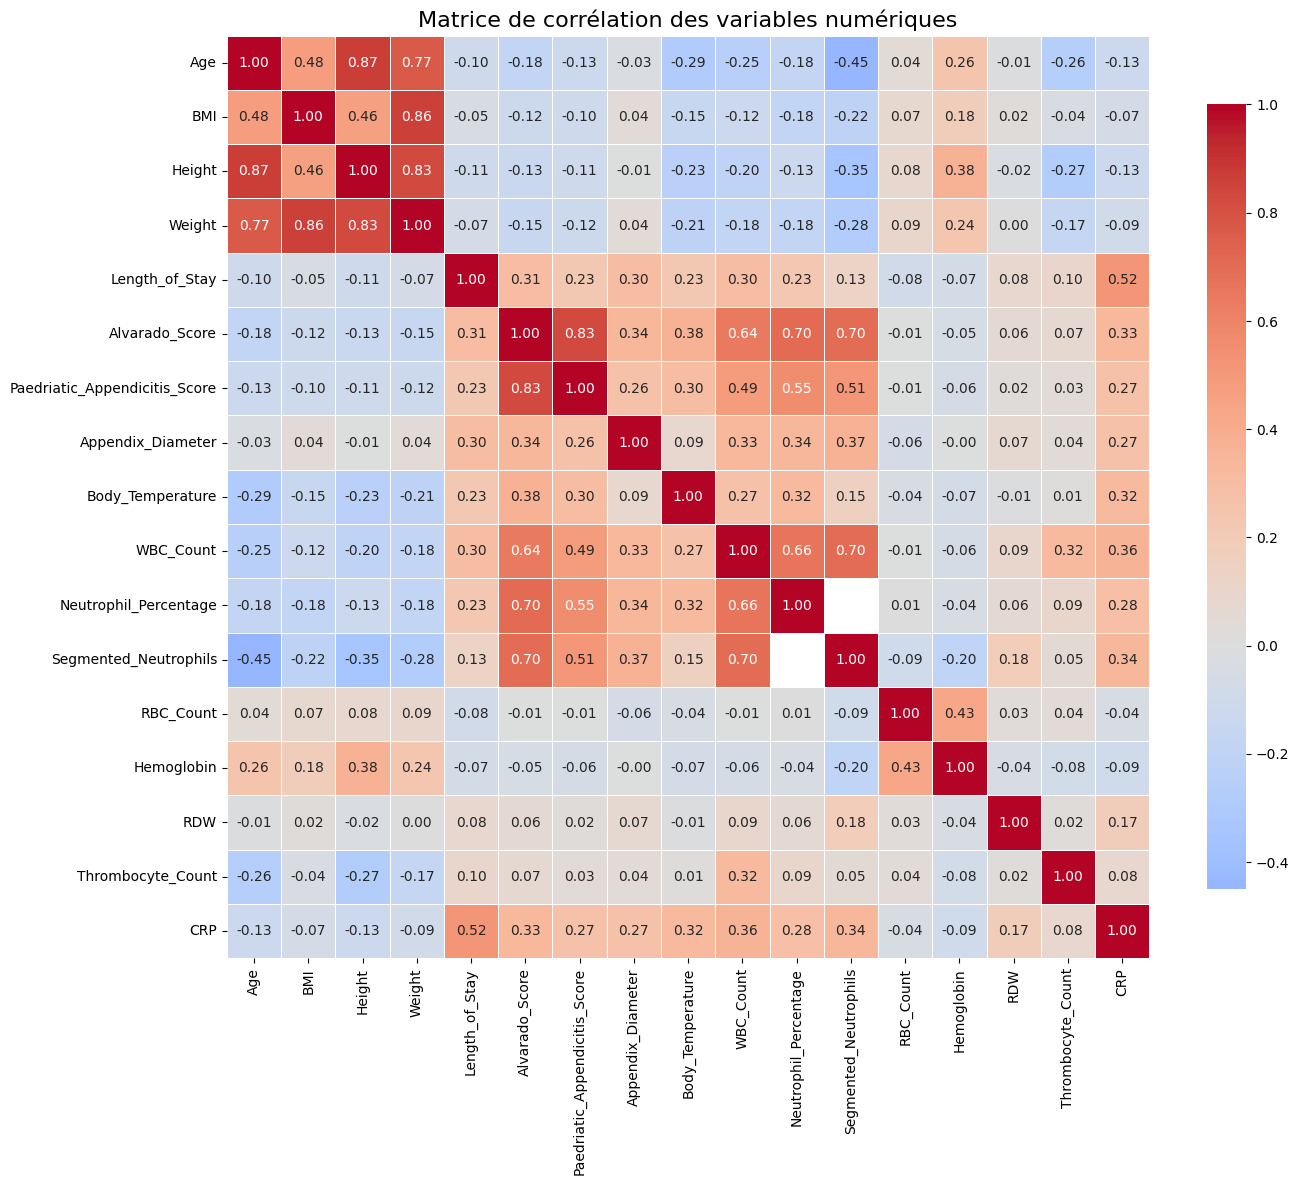

In [2]:
print("❓ QUESTION 3: Y a-t-il des corrélations fortes entre variables?")
print("="*60)

# Matrice de corrélation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numerical_cols].corr()

# Visualisation de la matrice
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrice de corrélation des variables numériques', fontsize=16)
plt.tight_layout()
plt.show()

🔍 RECHERCHE DES CORRÉLATIONS FORTES (>0.7)
⚠️ 6 paires de variables fortement corrélées trouvées:

                   Variable 1     Variable 2  Corrélation
                       Height            Age     0.865311
                       Weight            BMI     0.859187
Paedriatic_Appendicitis_Score Alvarado_Score     0.832473
                       Weight         Height     0.829532
                       Weight            Age     0.766495
        Neutrophil_Percentage Alvarado_Score     0.701133


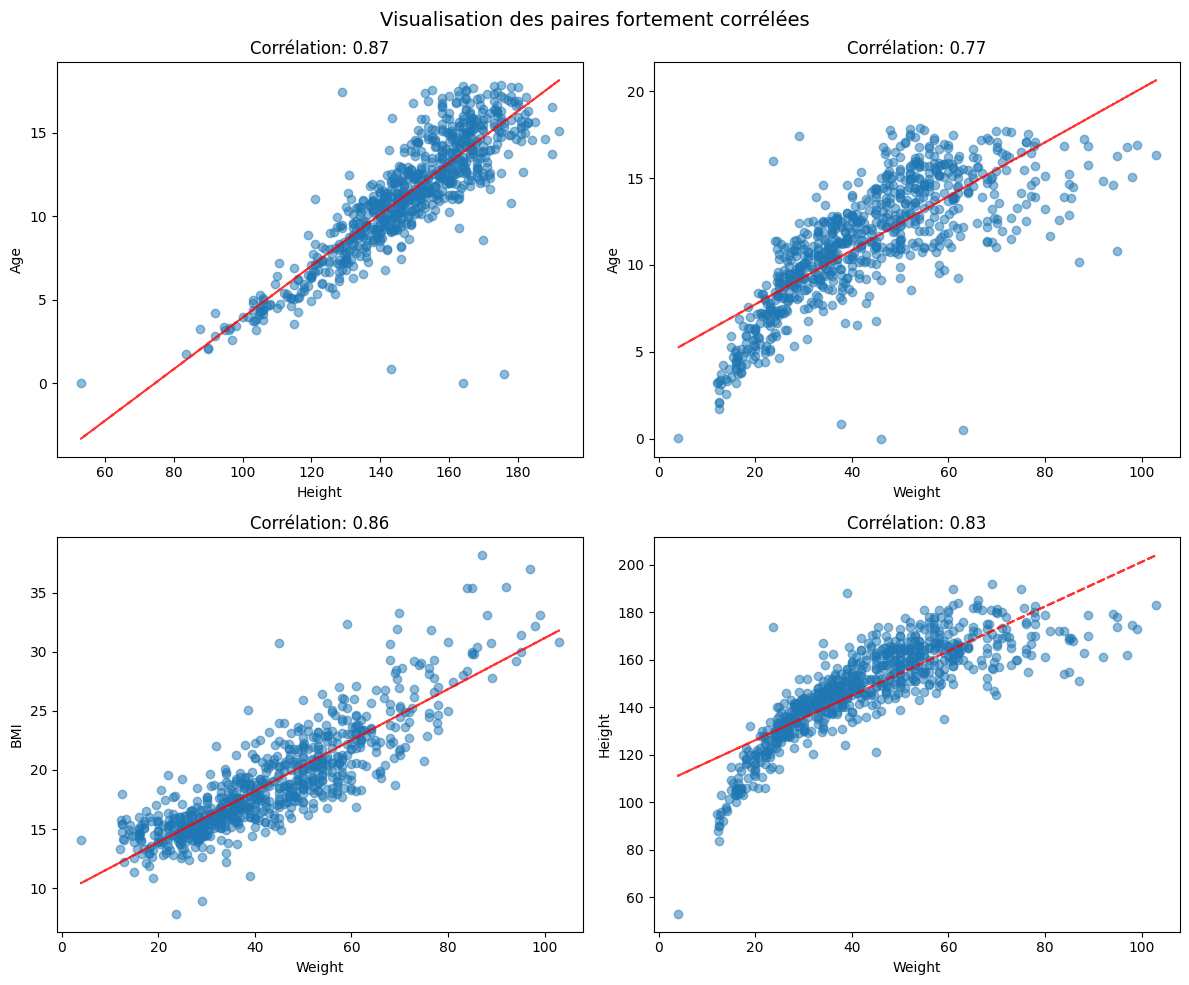

In [3]:
# Cellule: IDENTIFICATION DES CORRÉLATIONS FORTES (VERSION CORRIGÉE)
print("🔍 RECHERCHE DES CORRÉLATIONS FORTES (>0.7)")
print("="*50)

# Trouver les paires avec forte corrélation
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Corrélation': correlation_matrix.iloc[i, j]
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values('Corrélation', ascending=False)
    print(f"⚠️ {len(high_corr)} paires de variables fortement corrélées trouvées:\n")
    print(high_corr_df.to_string(index=False))
    
    # Visualisation des paires corrélées
    if len(high_corr) > 0:
        n_pairs = min(4, len(high_corr))
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.ravel()
        
        for idx, pair in enumerate(high_corr[:n_pairs]):
            var1 = pair['Variable 1']
            var2 = pair['Variable 2']
            
            # NETTOYER LES DONNÉES avant de les utiliser
            data_clean = df[[var1, var2]].dropna()  # Enlever les valeurs manquantes
            data_clean = data_clean[np.isfinite(data_clean[var1]) & np.isfinite(data_clean[var2])]  # Enlever les infinis
            
            if len(data_clean) > 2:  # Assez de données pour tracer
                # Nuage de points
                axes[idx].scatter(data_clean[var1], data_clean[var2], alpha=0.5)
                axes[idx].set_xlabel(var1)
                axes[idx].set_ylabel(var2)
                axes[idx].set_title(f'Corrélation: {pair["Corrélation"]:.2f}')
                
                # Ajouter une ligne de tendance (avec gestion d'erreur)
                try:
                    z = np.polyfit(data_clean[var1], data_clean[var2], 1)
                    p = np.poly1d(z)
                    axes[idx].plot(data_clean[var1], p(data_clean[var1]), "r--", alpha=0.8)
                except Exception as e:
                    print(f"⚠️ Pas de ligne de tendance pour {var1} vs {var2}: {e}")
                    axes[idx].text(0.5, 0.5, "Ligne non disponible", 
                                 transform=axes[idx].transAxes, ha='center')
            else:
                axes[idx].text(0.5, 0.5, "Pas assez de données", 
                             transform=axes[idx].transAxes, ha='center')
                axes[idx].set_title(f'{var1} vs {var2}')
        
        # Cacher les subplots vides
        for idx in range(n_pairs, 4):
            axes[idx].set_visible(False)
        
        plt.suptitle('Visualisation des paires fortement corrélées', fontsize=14)
        plt.tight_layout()
        plt.show()
else:
    print("✅ AUCUNE corrélation forte (>0.7) détectée!")

In [4]:
# CELLULE: PRISE DE DÉCISION SUR LES CORRÉLATIONS

print("📋 PRISE DE DÉCISION SUR LES CORRÉLATIONS FORTES")
print("="*70)
print("🔍 Analyse des 6 paires corrélées identifiées")
print("="*70)

# Définir les paires avec leurs corrélations (selon vos résultats)
paires_correlees = [
    {'var1': 'Height', 'var2': 'Age', 'correlation': 0.865},
    {'var1': 'Weight', 'var2': 'BMI', 'correlation': 0.859},
    {'var1': 'Paedriatic_Appendicitis_Score', 'var2': 'Alvarado_Score', 'correlation': 0.832},
    {'var1': 'Weight', 'var2': 'Height', 'correlation': 0.830},
    {'var1': 'Weight', 'var2': 'Age', 'correlation': 0.766},
    {'var1': 'Neutrophil_Percentage', 'var2': 'Alvarado_Score', 'correlation': 0.701}
]

# Créer un tableau pour stocker toutes les décisions
decisions_df = pd.DataFrame()

print("\n" + "="*70)
print("📊 ANALYSE DÉTAILLÉE PAR PAIRE")
print("="*70)

for i, paire in enumerate(paires_correlees, 1):
    var1 = paire['var1']
    var2 = paire['var2']
    corr = paire['correlation']
    
    print(f"\n🔹 PAIRE {i}: {var1} ↔ {var2} (r = {corr:.3f})")
    print("-"*50)
    
    # Décision basée sur la force de corrélation
    if corr > 0.95:
        niveau = "🔴 CRITIQUE"
        action = "SUPPRIMER UNE VARIABLE OBLIGATOIREMENT"
        raison = "Redondance presque parfaite (>95% d'information commune)"
        recommandation = f"Supprimer {var2} (moins pertinente) et garder {var1}"
    elif corr > 0.9:
        niveau = "🟠 TRÈS FORTE"
        action = "SUPPRIMER FORTEMENT RECOMMANDÉ"
        raison = "Information partagée >81%, risque élevé de multicollinéarité"
        recommandation = f"Supprimer {var2} ou créer un score composite"
    elif corr > 0.85:
        niveau = "🟡 FORTE"
        action = "À CONSIDÉRER - SURVEILLER"
        raison = "Information partagée >72%, risque de multicollinéarité"
        recommandation = f"Garder mais surveiller dans les modèles linéaires"
    elif corr > 0.8:
        niveau = "🟢 MODÉRÉE"
        action = "GARDER AVEC SURVEILLANCE"
        raison = "Information partagée >64%, acceptable mais à surveiller"
        recommandation = "Utiliser des modèles robustes (Random Forest)"
    else:
        niveau = "⚪ ACCEPTABLE"
        action = "GARDER"
        raison = "Information partagée <64%, pas de problème majeur"
        recommandation = "Aucune action nécessaire"
    
    print(f"Niveau: {niveau}")
    print(f"Action: {action}")
    print(f"Raison: {raison}")
    print(f"Recommandation: {recommandation}")
    
    # Ajouter au tableau des décisions
    decisions_df = pd.concat([decisions_df, pd.DataFrame([{
        'Paire': i,
        'Variable 1': var1,
        'Variable 2': var2,
        'Corrélation': f"{corr:.3f}",
        'Niveau': niveau,
        'Action': action,
        'Recommandation': recommandation
    }])], ignore_index=True)

print("\n" + "="*70)
print("📋 TABLEAU RÉCAPITULATIF DES DÉCISIONS")
print("="*70)
print(decisions_df.to_string(index=False))

📋 PRISE DE DÉCISION SUR LES CORRÉLATIONS FORTES
🔍 Analyse des 6 paires corrélées identifiées

📊 ANALYSE DÉTAILLÉE PAR PAIRE

🔹 PAIRE 1: Height ↔ Age (r = 0.865)
--------------------------------------------------
Niveau: 🟡 FORTE
Action: À CONSIDÉRER - SURVEILLER
Raison: Information partagée >72%, risque de multicollinéarité
Recommandation: Garder mais surveiller dans les modèles linéaires

🔹 PAIRE 2: Weight ↔ BMI (r = 0.859)
--------------------------------------------------
Niveau: 🟡 FORTE
Action: À CONSIDÉRER - SURVEILLER
Raison: Information partagée >72%, risque de multicollinéarité
Recommandation: Garder mais surveiller dans les modèles linéaires

🔹 PAIRE 3: Paedriatic_Appendicitis_Score ↔ Alvarado_Score (r = 0.832)
--------------------------------------------------
Niveau: 🟢 MODÉRÉE
Action: GARDER AVEC SURVEILLANCE
Raison: Information partagée >64%, acceptable mais à surveiller
Recommandation: Utiliser des modèles robustes (Random Forest)

🔹 PAIRE 4: Weight ↔ Height (r = 0.830)
---